In [1]:
from orcs.process import SpectralCube
from astropy.io import fits
from astropy.wcs import WCS
from astropy.visualization.wcsaxes import SphericalCircle
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.colors as colors
import numpy as np
from astropy.coordinates import SkyCoord
import astropy.units as u
import orb
import orb.utils.graph as graph
from scipy import constants
import pyregion

import numpy as np
import matplotlib.pyplot as plt
import orcs.process
import orcs.process
import pylab as pl
import orb.utils.io
import numpy as np
from importlib import reload
import pyregion
import orb.utils.graph as graph
from orcs.process import SpectralCube
import pylab as pl
import orb.utils.io
import numpy as np
import matplotlib.pyplot as plt

import orcs.process
import pylab as pl
import orb.utils.io
import numpy as np
from importlib import reload
import pyregion
import orb.utils.graph as graph
from orcs.process import SpectralCube
import pylab as pl
import orb.utils.io
import numpy as np
import matplotlib.pyplot as plt
import astropy.cosmology as cosmo
from orcs.process import SpectralCube
from astropy.io import fits
from astropy.wcs import WCS
from astropy.visualization.wcsaxes import SphericalCircle
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.colors as colors
import numpy as np
from astropy.coordinates import SkyCoord
import astropy.units as u
import orb
import orb.utils.graph as graph
from scipy import constants
import pyregion

from astropy.convolution import convolve, Gaussian2DKernel
from astropy.convolution import interpolate_replace_nans

In [2]:
data_path = '/Users/leianydeoleo/Desktop/IIZw96/'

cube_SN2 = SpectralCube(data_path + 'SN2.hdf5')

deep_SN2 = cube_SN2.get_deep_frame()
deep_SN2_hdu = fits.open(data_path + 'deep_frame.fits')
wcs = WCS(deep_SN2_hdu[0].header)

xpix_bkgd, ypix_bkgd = 950, 950
# extract and plot a spectrum representative of the background around IIZw96
spectrum_background = cube_SN2.get_spectrum(xpix_bkgd, ypix_bkgd, 2) # option mean_flux

unknown|WARNING| old cube architecture (level 1). IO performances could be reduced.
unknown|INFO| Cube is level 1
unknown|INFO| shape: (2048, 2064, 113)
unknown|INFO| wavenumber calibration: True
unknown|INFO| flux calibration: True
unknown|INFO| wcs calibration: False


 [==========] [100%] [completed in 0.023 s]                                   


spec = cube_SN2.get_spectrum(1023.5, 1031.5, 3)
vel, fluxes = spec.estimate_parameters(('[OIII]4959', 'Hbeta', '[OIII]5007'), [-6000, 6000])
print('velocity estimate (km/s)', vel)
print('fluxes estimate (erg/cm^2/s)', fluxes)

In [4]:
#redo fitting

amp_ratio = cube_SN2.get_amp_ratio_from_flux_ratio('[OIII]5007','[OIII]4959', 3.01)

#new_vel = 89 # km/s
fit = cube_SN2.fit_lines_in_region(('/Users/leianydeoleo/Desktop/IIZw96/SN2_Region.reg'),
('[OIII]5007','Hbeta', '[OIII]4959'),
fmodel='sincgauss',
pos_def=['1','1','1'],
pos_cov = [11232],
sigma_def=['1','1','1'],
sigma_cov = [20],          
nofilter=True,
amp_def=['1', '2', '1'],
amp_guess=[1, 1, amp_ratio], 
binning=1)

unknown|INFO| creating output file for 20 parameters x 3 lines (1.01449728 Go)
unknown|INFO|  > allocating: height
unknown|INFO|  > allocating: height-err
unknown|INFO|  > allocating: amplitude
unknown|INFO|  > allocating: amplitude-err
unknown|INFO|  > allocating: velocity
unknown|INFO|  > allocating: velocity-err
unknown|INFO|  > allocating: fwhm
unknown|INFO|  > allocating: fwhm-err
unknown|INFO|  > allocating: sigma
unknown|INFO|  > allocating: sigma-err
unknown|INFO|  > allocating: flux
unknown|INFO|  > allocating: flux-err
unknown|INFO|  > allocating: logGBF
unknown|INFO|  > allocating: chi2
unknown|INFO|  > allocating: rchi2
unknown|INFO|  > allocating: ks_pvalue
unknown|INFO|  > allocating: cont_p0
unknown|INFO|  > allocating: cont_p1
unknown|INFO|  > allocating: cont_p2
unknown|INFO|  > allocating: cont_p3
unknown|INFO| Number of spectra to fit: 27672
unknown|WARNING| /opt/anaconda3/envs/orb3/lib/python3.10/site-packages/orcs/core.py:166: RuntimeWarning: invalid value encounte

 [==========] [100%] [completed in 0.189 s]                                   


unknown|INFO| fitting started at 2026-08-04 14:05:04.837265
unknown|INFO| Init of the parallel processing server with 8 threads
unknown|INFO| passed mapped kwargs : []
unknown|WARNING| /opt/anaconda3/envs/orb3/lib/python3.10/site-packages/orb/utils/image.py:1120: RuntimeWarning: Mean of empty slice
  return np.squeeze(np.nanmean(np.nanmean(im_view, axis=3), axis=1))

unknown|INFO| 188 rows to fit
unknown|WARNING| /opt/anaconda3/envs/orb3/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)



 [========= ] [90%] [2.34s/pix|2.25h] 6s|23m17s]                           

 [========= ] [92%] [2.32s/pix|2.23h] 22s|17m50s]Traceback (most recent call last):
  File "/opt/anaconda3/envs/orb3/lib/python3.10/site-packages/orb/fft.py", line 884, in prepared_fit
    _fit = orb.fit._fit_lines_in_spectrum(
  File "/opt/anaconda3/envs/orb3/lib/python3.10/site-packages/orb/fit.py", line 2680, in _fit_lines_in_spectrum
    fit = fv.fit(compute_mcmc_error=compute_mcmc_error)
  File "/opt/anaconda3/envs/orb3/lib/python3.10/site-packages/orb/fit.py", line 457, in fit
    fit_results = scipy.optimize.curve_fit(
  File "/opt/anaconda3/envs/orb3/lib/python3.10/site-packages/scipy/optimize/_minpack_py.py", line 885, in curve_fit
    _, s, VT = svd(res.jac, full_matrices=False)
  File "/opt/anaconda3/envs/orb3/lib/python3.10/site-packages/scipy/linalg/_decomp_svd.py", line 108, in svd
    a1 = _asarray_validated(a, check_finite=check_finite)
  File "/opt/anaconda3/envs/orb3/lib/python3.10/site-packages/scipy/_lib/_util.py", line 252, in _asarray_validated
    a = toarray(a)


unknown|INFO| Closing parallel processing server


unknown|INFO| Writing height maps
unknown|WARNING| param height is the same for all lines
unknown|INFO| Data written as ./IIZw96_SN2/MAPS/IIZw96_SN2.LineMaps.map.all.1x1.height.fits in 0.08 s 
unknown|INFO| Writing height-err maps
unknown|WARNING| param height-err is the same for all lines
unknown|INFO| Data written as ./IIZw96_SN2/MAPS/IIZw96_SN2.LineMaps.map.all.1x1.height-err.fits in 0.05 s 
unknown|INFO| Writing amplitude maps
unknown|INFO| Data written as ./IIZw96_SN2/MAPS/IIZw96_SN2.LineMaps.map.5007.1x1.amplitude.fits in 0.05 s 
unknown|INFO| Data written as ./IIZw96_SN2/MAPS/IIZw96_SN2.LineMaps.map.4861.1x1.amplitude.fits in 0.05 s 
unknown|INFO| Data written as ./IIZw96_SN2/MAPS/IIZw96_SN2.LineMaps.map.4959.1x1.amplitude.fits in 0.06 s 
unknown|INFO| Writing amplitude-err maps
unknown|INFO| Data written as ./IIZw96_SN2/MAPS/IIZw96_SN2.LineMaps.map.5007.1x1.amplitude-err.fits in 0.05 s 
unknown|INFO| Data written as ./IIZw96_SN2/MAPS/IIZw96_SN2.LineMaps.map.4861.1x1.amplitude-e

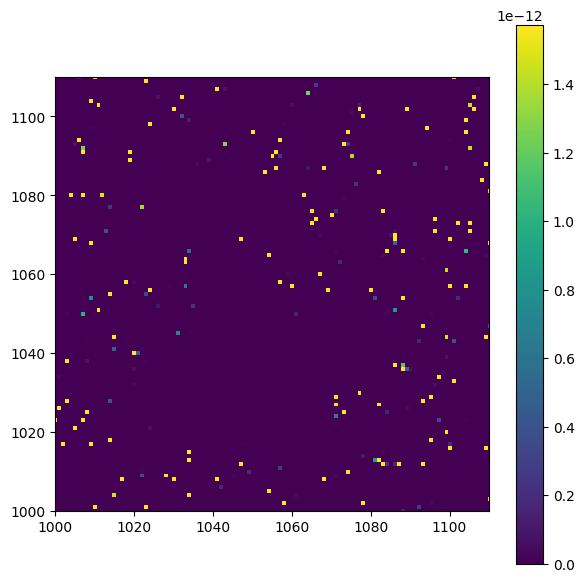

In [6]:
flux = orb.utils.io.read_fits('/Users/leianydeoleo/Desktop/IIZW96/IIZw96_SN2/MAPS/IIZw96_SN2.LineMaps.map.4861.1x1.flux.fits') 
graph.imshow(flux)
pl.xlim(1000, 1110)
pl.ylim(1000, 1110)
pl.colorbar()